# Battery size optimization — continuous MILP sweep

Perfect-foresight cost of one household over a full year, solved once per battery capacity
from 0 to 100 kWh in the continuous formulation, so each point is the theoretical optimum
for that capacity.

The household has a PV self-supply device, so the price list is *GEN-I Dinamični –
Samooskrba* (`GENI_SAMO_DINAMICNI`, `si_samooskrba`): import at SIPX + 0.01199 EUR/kWh plus
network charges, contributions and VAT, export credited at SIPX − 0.01199 EUR/kWh.

One MILP per capacity over the whole 35 136-step year, solved to a 0.1 % MIP gap. Every
solve starts and is required to end at half capacity, so a larger battery cannot book the
sell-off of its own opening charge as a saving.

In [1]:
### Imports
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import pulp
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

import importlib
import Battery_Economics as be
import Data_Loader as dl
import Environment as environment_module
import MILP_Household as milp_module

dl = importlib.reload(dl)
environment_module = importlib.reload(environment_module)
milp_module = importlib.reload(milp_module)

HouseholdEnvironment = environment_module.HouseholdEnvironment
solve_household = milp_module.solve_household

print("Imports ready.")

Imports ready.


## 1. Configuration

In [2]:
### Household / dataset -----------------------------------------------------
HOUSEHOLD_ID = 29
DATASET_NAME = "Fluvius_PV"        # PV household -> GEN-I samooskrba dynamic list
SMP_COUNTRY_ID = "Slovenia"

PRICE_COLUMN = "SMP"
GENERATION_COLUMN = "Feed_In_Volume_kWh"
CONSUMPTION_COLUMN = "Consumption_Volume_kWh"

### Tariff ------------------------------------------------------------------
PRICING_SCHEME = "si_samooskrba"
PAKET_ID = "GENI_SAMO_DINAMICNI"   # GEN-I Dinamični – Samooskrba GENI_SAMO_AKTIVNI doseže boljše rezultate
PRICING_REFERENCE_YEAR = 2026      # dataset is 2024; SI tariff regime to price under
PEAK_RESET_MONTHS = 1           # repository default: ratchet peak never resets

### Battery -----------------------------------------------------------------
BATTERY_SIZES_KWH = np.unique(np.concatenate([
    np.arange(0.0, 11.0, 1.0),     # fine where the curve bends
    np.arange(12.5, 30.0, 2.5),
    np.arange(30.0, 101.0, 10.0),
]))

# Taken from MILP_Household rather than retyped, so every study in the
# repository sizes the same battery and solves it to the same gap.
CHARGE_EFFICIENCY = milp_module.CHARGE_EFFICIENCY
DISCHARGE_EFFICIENCY = milp_module.DISCHARGE_EFFICIENCY

# Power rating scales with capacity, capped at the inverter limit.
C_RATE = milp_module.C_RATE                 # kW per kWh of capacity
INVERTER_MAX_KW = milp_module.INVERTER_MAX_KW

SOC_FRACTION = milp_module.SOC_FRACTION     # start AND end each solve at this share of capacity

### Solver ------------------------------------------------------------------
SOLVER_GAP_REL = milp_module.FULL_PERIOD_GAP_REL       # 0.1 % MIP gap
SOLVER_TIME_LIMIT_S = milp_module.FULL_PERIOD_TIME_LIMIT_S

### Battery operating envelope ----------------------------------------------
# Off by default, so this notebook reproduces what it produced before.
#
# MAX_DAILY_CYCLES counts against the USABLE window: set it to 2 and the pack may
# be swept soc_min -> soc_max -> soc_min twice, after which it neither charges nor
# discharges again that local day. CYCLE_COST prices wear into the MILP objective
# so the solver stops buying arbitrage that does not cover its own degradation --
# a shadow price, never added to Cost_EUR.
MAX_DAILY_CYCLES = None            # usable-window cycles per local day; try 2.0
SOC_MIN_FRAC = 0.0                 # unusable reserve at the bottom of the pack
SOC_MAX_FRAC = 1.0                 # unusable headroom at the top
CYCLE_COST_ENABLED = False         # price wear into the MILP objective

### Economics --------------------------------------------------------------
# Taken from Battery_Economics rather than retyped, like the battery constants
# above come from MILP_Household. This study keeps the simpler capex model —
# no fixed install fee, and a flat calendar life rather than a cycle-limited one
# — so it passes those two explicitly wherever it calls the shared helpers.
CAPEX_SCENARIOS_EUR_PER_KWH = [150.0, 250.0, 350.0, 450.0, 550.0]  # EUR per kWh of battery capacity
# The middle scenario, used wherever one price has to stand for the sweep: the
# payback column, the O&M charge, and the wear price if it is switched on.
REFERENCE_CAPEX = CAPEX_SCENARIOS_EUR_PER_KWH[len(CAPEX_SCENARIOS_EUR_PER_KWH) // 2]
BATTERY_LIFETIME_YEARS = be.BATTERY_CALENDAR_LIFE_Y
BATTERY_CYCLE_LIMIT_EFC = be.BATTERY_CYCLE_LIMIT_EFC   # only used by the wear price
DISCOUNT_RATE = be.DISCOUNT_RATE
OPEX_FRAC_OF_CAPEX_PER_YEAR = be.OPEX_FRAC_OF_CAPEX_PER_YEAR   # yearly O&M, share of capex

print(f"{len(BATTERY_SIZES_KWH)} battery sizes: {BATTERY_SIZES_KWH}")

26 battery sizes: [  0.    1.    2.    3.    4.    5.    6.    7.    8.    9.   10.   12.5
  15.   17.5  20.   22.5  25.   27.5  30.   40.   50.   60.   70.   80.
  90.  100. ]


## 2. Load the household and the SMP price series

In [3]:
input_data = dl.load_household_data(HOUSEHOLD_ID, dataset=DATASET_NAME)

smp_country = dl.load_smp_data(SMP_COUNTRY_ID)
smp_aligned = smp_country.reindex(input_data.index, method="ffill")
smp_series = pd.to_numeric(smp_aligned[PRICE_COLUMN], errors="coerce").ffill().bfill()

# Auto-detect legacy EUR/MWh inputs and convert to EUR/kWh.
smp_scale = 1000.0 if float(smp_series.abs().quantile(0.95)) > 2.0 else 1.0
input_data[PRICE_COLUMN] = (smp_series / smp_scale).astype(float)

step_minutes = float(
    input_data.index.to_series().sort_values().diff().dropna().dt.total_seconds().median() / 60.0
)
STEPS_PER_DAY = int(round(1440.0 / step_minutes))
HOURS_PER_STEP = 24.0 / STEPS_PER_DAY

period_days = (input_data.index[-1] - input_data.index[0]).total_seconds() / 86400.0
ANNUALIZE = 365.0 / period_days

annual_consumption_kwh = float(input_data[CONSUMPTION_COLUMN].sum()) * ANNUALIZE
annual_generation_kwh = float(input_data[GENERATION_COLUMN].sum()) * ANNUALIZE

print(f"Household {HOUSEHOLD_ID} ({DATASET_NAME}): {len(input_data)} intervals of "
      f"{step_minutes:.0f} min, {input_data.index[0]:%Y-%m-%d} -> {input_data.index[-1]:%Y-%m-%d} "
      f"({period_days:.1f} days)")
print(f"Consumption {annual_consumption_kwh:,.0f} kWh/a | PV feed-in "
      f"{annual_generation_kwh:,.0f} kWh/a | SMP {input_data[PRICE_COLUMN].min():.3f} .. "
      f"{input_data[PRICE_COLUMN].max():.3f} EUR/kWh (median "
      f"{input_data[PRICE_COLUMN].median():.3f})")
if annual_generation_kwh <= 0:
    print("WARNING: no PV in this profile — pricing_scheme='si_samooskrba' has nothing to net.")

Household 29 (Fluvius_PV): 35136 intervals of 15 min, 2024-01-01 -> 2024-12-31 (366.0 days)
Consumption 1,906 kWh/a | PV feed-in 1,268 kWh/a | SMP -0.106 .. 1.022 EUR/kWh (median 0.086)


## 3. Environment + chained monthly MILP

`build_env(capacity_kwh)` returns the environment the MILP reads its battery and tariff
parameters off; `solve_year(env)` solves the whole year in the continuous formulation.

In [4]:
def build_env(capacity_kwh, dataset=None):
    '''Environment for one battery capacity. Power rating scales with capacity.'''
    dataset = input_data if dataset is None else dataset
    return milp_module.build_household_env(
        dataset,
        capacity_kwh=capacity_kwh,
        scheme=PRICING_SCHEME,
        paket_id=PAKET_ID,
        pricing_reference_year=PRICING_REFERENCE_YEAR,
        peak_reset_months=PEAK_RESET_MONTHS,
        price_column=PRICE_COLUMN,
        generation_column=GENERATION_COLUMN,
        consumption_column=CONSUMPTION_COLUMN,
        steps_per_day=STEPS_PER_DAY,
        # Battery properties are forwarded rather than left to the MILP_Household
        # defaults: the reported Power_kW and the cycle accounting are computed from
        # these same constants, so a change in the configuration cell has to reach the
        # solve or the two silently disagree.
        c_rate=C_RATE,
        inverter_max_kw=INVERTER_MAX_KW,
        charge_efficiency=CHARGE_EFFICIENCY,
        discharge_efficiency=DISCHARGE_EFFICIENCY,
        # The operating envelope. `capacity_kwh` stays the NAMEPLATE pack — a SOC
        # window derates what the physics sees, not what the economics pay for.
        soc_min_frac=SOC_MIN_FRAC,
        soc_max_frac=SOC_MAX_FRAC,
        max_daily_cycles=MAX_DAILY_CYCLES,
        cycle_cost_eur_per_efc=(
            be.cycle_cost_eur_per_efc(capacity_kwh, REFERENCE_CAPEX, BATTERY_CYCLE_LIMIT_EFC)
            if CYCLE_COST_ENABLED and capacity_kwh > 0 else None
        ),
    )


SOLVER = milp_module.full_period_solver(SOLVER_GAP_REL, SOLVER_TIME_LIMIT_S)


def solve_year(env):
    '''One continuous MILP over the whole horizon. Starts and ends at
    SOC_FRACTION of capacity, so no capacity gets free energy at t=0.'''
    soc_kwh = SOC_FRACTION * env.battery_capacity_kwh
    return solve_household(
        env,
        initial_soc_kwh=soc_kwh,
        final_soc_kwh=soc_kwh,
        solver=SOLVER,
        verbose=False,
    )


def summarize(df, capacity_kwh, env):
    '''Per-capacity metrics extracted from a solved trajectory.'''
    return milp_module.summarize_trajectory(
        df,
        # The usable window is what the trajectory moved energy within; the
        # nameplate is what the economics pay for and what EFC counts against.
        capacity_kwh=env.battery_capacity_kwh,
        nominal_capacity_kwh=capacity_kwh,
        hours_per_step=HOURS_PER_STEP,
        annualize=ANNUALIZE,
        charge_efficiency=CHARGE_EFFICIENCY,
        discharge_efficiency=DISCHARGE_EFFICIENCY,
        # This notebook counts cycles AC-side, on discharge alone.
        efc_convention="ac",
    ) | {"Power_kW": min(C_RATE * float(capacity_kwh), INVERTER_MAX_KW)}


print("Helpers defined.")

Helpers defined.


## 4. Sweep 0 → 100 kWh

In [5]:
%%time
results = []
trajectories = {}
sweep_start = time.time()

for capacity in BATTERY_SIZES_KWH:
    t0 = time.time()
    env = build_env(capacity)
    df_year = solve_year(env)
    row = summarize(df_year, capacity, env)
    row["Solve_s"] = time.time() - t0
    results.append(row)
    trajectories[float(capacity)] = df_year
    print(f"  {capacity:6.1f} kWh @ {row['Power_kW']:5.2f} kW -> "
          f"{row['Cost_EUR']:9.2f} EUR/a   "
          f"({row['Equivalent_Full_Cycles']:5.1f} full cycles, {row['Solve_s']:5.1f} s)",
          flush=True)

df_sizing = pd.DataFrame(results).sort_values("Capacity_kWh").reset_index(drop=True)
print(f"\nSweep finished in {(time.time() - sweep_start) / 60:.1f} min.")

     0.0 kWh @  0.00 kW ->    485.29 EUR/a   (  0.0 full cycles,   7.2 s)
     1.0 kWh @  0.50 kW ->    441.93 EUR/a   (441.7 full cycles,  43.3 s)
     2.0 kWh @  1.00 kW ->    406.28 EUR/a   (400.0 full cycles,  45.8 s)
     3.0 kWh @  1.50 kW ->    372.57 EUR/a   (377.3 full cycles,  46.9 s)
     4.0 kWh @  2.00 kW ->    341.90 EUR/a   (360.4 full cycles,  47.1 s)
     5.0 kWh @  2.50 kW ->    313.02 EUR/a   (346.6 full cycles,  49.2 s)
     6.0 kWh @  3.00 kW ->    285.52 EUR/a   (335.0 full cycles, 125.7 s)
     7.0 kWh @  3.50 kW ->    259.38 EUR/a   (324.7 full cycles, 123.6 s)
     8.0 kWh @  4.00 kW ->    234.30 EUR/a   (315.9 full cycles, 128.4 s)
     9.0 kWh @  4.50 kW ->    209.81 EUR/a   (308.1 full cycles, 113.5 s)
    10.0 kWh @  5.00 kW ->    185.80 EUR/a   (301.3 full cycles, 118.0 s)
    12.5 kWh @  6.25 kW ->    127.36 EUR/a   (287.2 full cycles, 151.6 s)
    15.0 kWh @  7.50 kW ->     71.98 EUR/a   (275.2 full cycles,  71.4 s)
    17.5 kWh @  8.75 kW ->     17.62 E

## 5. Savings and battery economics

`Savings_EUR` is measured against the 0 kWh solve. Capital and savings are put on the same
yearly footing with the capital recovery factor

    a = r / (1 - (1 + r)^-n)         r = DISCOUNT_RATE, n = BATTERY_LIFETIME_YEARS

and O&M is charged as a flat share of the same capital

    o = OPEX_FRAC_OF_CAPEX_PER_YEAR

so a battery of size `C` at `capex` EUR/kWh costs `C * capex * (a + o)` per year and

    net annual benefit(C) = savings(C) - C * capex * (a + o)

`Break_Even_Capex = savings(C) / (C * (a + o))` is the installed cost at which that size breaks
even; `Payback_y = C * capex / net_savings(C)` is simple undiscounted payback, measured on
savings after O&M.

**What this study leaves out**, compared with `Multuser_Battery_Size_Optimization`: there is no
fixed install fee — `capex(C) = C * capex_per_kwh` with nothing added — and the service life is a
flat `BATTERY_LIFETIME_YEARS`, not shortened when the pack is cycled hard. One household on one
contract is a curve, not an appraisal; the multi-household study is where the cycle-limited life
and the install fee are carried.


In [6]:
cost_no_battery = float(df_sizing.loc[df_sizing["Capacity_kWh"] == 0.0, "Cost_EUR"].iloc[0])

# What a euro of installed capital costs per year: capital recovery plus O&M.
# Both come from Battery_Economics, so this study and the multi-household one
# cannot drift apart on either.
annuity_factor = be.capital_recovery_factor(DISCOUNT_RATE, BATTERY_LIFETIME_YEARS)
opex_factor = OPEX_FRAC_OF_CAPEX_PER_YEAR
yearly_cost_factor = be.annualized_cost_factor(
    DISCOUNT_RATE, BATTERY_LIFETIME_YEARS, opex_factor
)

df_sizing["Savings_EUR"] = cost_no_battery - df_sizing["Cost_EUR"]

# Marginal value of the next kWh of capacity (EUR per kWh per year).
df_sizing["Marginal_EUR_per_kWh"] = (
    df_sizing["Savings_EUR"].diff() / df_sizing["Capacity_kWh"].diff()
)

# Cost per kWh of capacity at which a battery of this size just breaks even.
# O&M is proportional to the same capital, so it joins the recovery factor in the
# denominator rather than the numerator.
df_sizing["Break_Even_Capex"] = np.where(
    df_sizing["Capacity_kWh"] > 0,
    df_sizing["Savings_EUR"] / (df_sizing["Capacity_kWh"] * yearly_cost_factor),
    np.nan,
)

for capex in CAPEX_SCENARIOS_EUR_PER_KWH:
    df_sizing[f"Net_{int(capex)}"] = (
        df_sizing["Savings_EUR"] - df_sizing["Capacity_kWh"] * capex * yearly_cost_factor
    )

# Simple (undiscounted) payback at the middle capex scenario (REFERENCE_CAPEX,
# section 1). Measured on savings NET of O&M: a battery that saves less per year
# than it costs to keep running never pays back at all, which the raw savings
# would hide.
df_sizing["Annual_OPEX_EUR"] = df_sizing["Capacity_kWh"] * REFERENCE_CAPEX * opex_factor
df_sizing["Net_Savings_EUR"] = df_sizing["Savings_EUR"] - df_sizing["Annual_OPEX_EUR"]
df_sizing["Payback_y"] = np.where(
    df_sizing["Net_Savings_EUR"] > 0,
    df_sizing["Capacity_kWh"] * REFERENCE_CAPEX / df_sizing["Net_Savings_EUR"].replace(0, np.nan),
    np.nan,
)

max_savings = float(df_sizing["Savings_EUR"].max())
knee_kwh = float(
    df_sizing.loc[df_sizing["Savings_EUR"] >= 0.95 * max_savings, "Capacity_kWh"].min()
)

print(f"Capital recovery factor a = r/(1-(1+r)^-n) = {annuity_factor:.4f} "
      f"(n = {BATTERY_LIFETIME_YEARS} y service life, r = {DISCOUNT_RATE:.0%})")
print(f"O&M {opex_factor:.1%} of capex per year -> yearly cost factor "
      f"a + o = {yearly_cost_factor:.4f}")
print(f"  -> 1 kWh of storage at {REFERENCE_CAPEX:,.0f} EUR/kWh costs "
      f"{REFERENCE_CAPEX * yearly_cost_factor:,.2f} EUR per year "
      f"({REFERENCE_CAPEX * annuity_factor:,.2f} capital + "
      f"{REFERENCE_CAPEX * opex_factor:,.2f} O&M)")
print(f"Cost without battery: {cost_no_battery:,.2f} EUR/a")
print(f"Max savings over the sweep: {max_savings:,.2f} EUR/a at "
      f"{float(df_sizing.loc[df_sizing['Savings_EUR'].idxmax(), 'Capacity_kWh']):.0f} kWh")
print(f"95 % of that is already reached at {knee_kwh:.0f} kWh")

display_cols = [
    "Capacity_kWh", "Power_kW", "Cost_EUR", "Savings_EUR", "Annual_OPEX_EUR",
    "Net_Savings_EUR", "Marginal_EUR_per_kWh",
    "Break_Even_Capex", "Payback_y", "Discharged_kWh", "Grid_Charged_kWh",
    "Equivalent_Full_Cycles", "Peak_Import_kW",
]
df_sizing[display_cols].round(2)

Capital recovery factor a = r/(1-(1+r)^-n) = 0.1128 (n = 12 y service life, r = 5%)
O&M 1.5% of capex per year -> yearly cost factor a + o = 0.1278
  -> 1 kWh of storage at 350 EUR/kWh costs 44.74 EUR per year (39.49 capital + 5.25 O&M)
Cost without battery: 485.29 EUR/a
Max savings over the sweep: 974.05 EUR/a at 100 kWh
95 % of that is already reached at 90 kWh


,Capacity_kWh,Power_kW,Cost_EUR,Savings_EUR,Annual_OPEX_EUR,Net_Savings_EUR,Marginal_EUR_per_kWh,Break_Even_Capex,Payback_y,Discharged_kWh,Grid_Charged_kWh,Equivalent_Full_Cycles,Peak_Import_kW
0,0.0,0.00,485.29,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,0.00,6.86
1,1.0,0.50,441.93,43.36,5.25,38.11,43.36,339.20,9.18,441.73,347.54,441.73,6.38
2,2.0,1.00,406.28,79.01,10.50,68.51,35.65,309.06,10.22,799.98,630.87,399.99,6.48
3,3.0,1.50,372.57,112.72,15.75,96.97,33.71,293.95,10.83,1131.84,896.86,377.28,6.48
4,4.0,2.00,341.90,143.39,21.00,122.39,30.67,280.44,11.44,1441.58,1150.94,360.39,6.48
5,5.0,2.50,313.02,172.27,26.25,146.02,28.88,269.54,11.98,1732.94,1397.33,346.59,6.48
6,6.0,3.00,285.52,199.77,31.50,168.27,27.50,260.47,12.48,2010.21,1639.43,335.03,6.48
7,7.0,3.50,259.38,225.91,36.75,189.16,26.14,252.48,12.95,2272.94,1880.71,324.71,6.84
8,8.0,4.00,234.30,250.98,42.00,208.98,25.07,245.44,13.40,2526.86,2124.43,315.86,6.48
9,9.0,4.50,209.81,275.48,47.25,228.23,24.49,239.46,13.80,2773.23,2367.52,308.14,6.48


## 6. Plots

In [7]:
### Shared chart styling
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8b8a84", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110,
})
EUR = FuncFormatter(lambda v, _: f"{v:,.0f}")


def finish(ax, title, xlabel, ylabel, subtitle=None):
    ax.set_title(title if subtitle is None else f"{title}\n{subtitle}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(EUR)
    return ax


print("Style ready.")

Style ready.


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


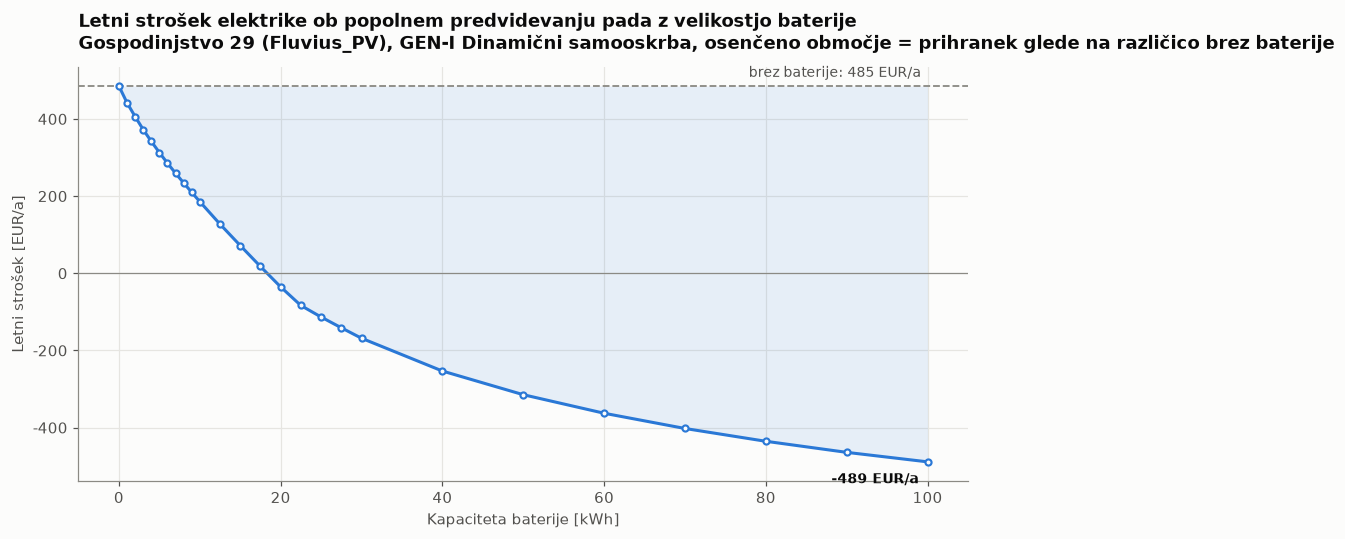

In [8]:
### Annual electricity cost vs battery size
fig, ax = plt.subplots(figsize=(9, 5))
cap = df_sizing["Capacity_kWh"]

ax.axhline(cost_no_battery, color=MUTED, lw=1.2, ls="--")
ax.annotate(f"brez baterije: {cost_no_battery:,.0f} EUR/a",
            xy=(cap.max(), cost_no_battery), xytext=(-4, 6),
            textcoords="offset points", ha="right", color=INK_2, fontsize=9)
ax.fill_between(cap, df_sizing["Cost_EUR"], cost_no_battery,
                color=SERIES[0], alpha=0.10, lw=0)
ax.plot(cap, df_sizing["Cost_EUR"], color=SERIES[0], lw=2,
        marker="o", ms=4, mfc=SURFACE, mew=1.4)
ax.axhline(0, color=MUTED, lw=0.8)

ax.annotate(f"{df_sizing['Cost_EUR'].iloc[-1]:,.0f} EUR/a",
            xy=(cap.iloc[-1], df_sizing["Cost_EUR"].iloc[-1]), xytext=(-6, -14),
            textcoords="offset points", ha="right", color=INK, fontsize=9,
            fontweight="semibold")

finish(ax, "Letni strošek elektrike ob popolnem predvidevanju pada z velikostjo baterije",
       "Kapaciteta baterije [kWh]", "Letni strošek [EUR/a]",
       f"Gospodinjstvo {HOUSEHOLD_ID} ({DATASET_NAME}), GEN-I Dinamični samooskrba, "
       f"osenčeno območje = prihranek glede na različico brez baterije")
plt.tight_layout()
plt.show()

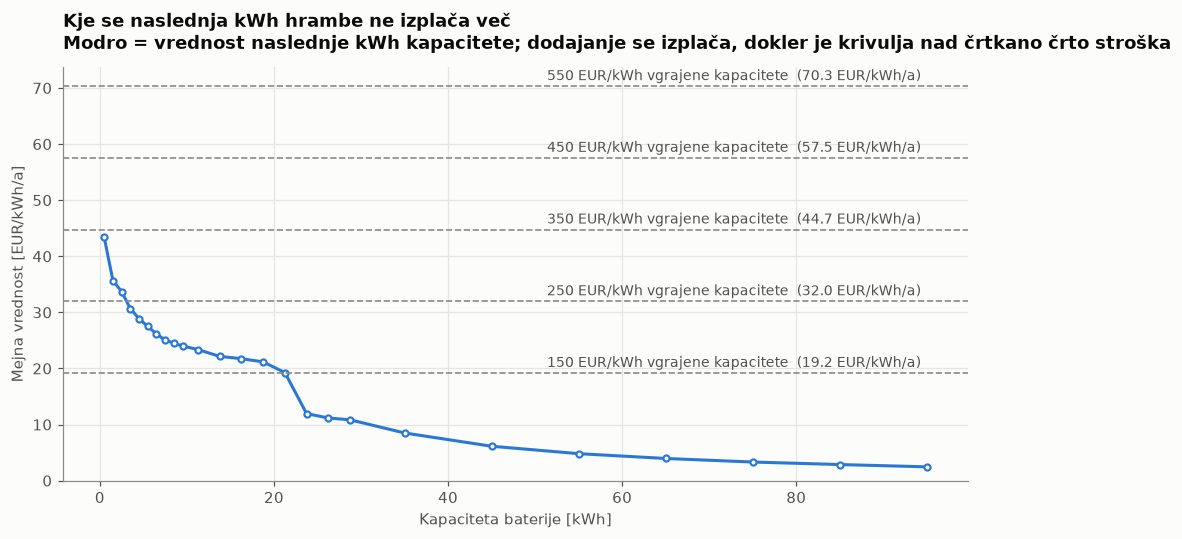

In [9]:
### Marginal value of capacity vs what capacity costs
fig, ax = plt.subplots(figsize=(9, 5))
mid = (df_sizing["Capacity_kWh"] + df_sizing["Capacity_kWh"].shift()) / 2

ax.plot(mid, df_sizing["Marginal_EUR_per_kWh"], color=SERIES[0], lw=2,
        marker="o", ms=4, mfc=SURFACE, mew=1.4)

for capex in CAPEX_SCENARIOS_EUR_PER_KWH:
    # Capital recovery plus O&M: what owning that kWh costs for a year.
    level = capex * yearly_cost_factor
    ax.axhline(level, color=MUTED, lw=1.1, ls="--")
    ax.annotate(f"{capex:,.0f} EUR/kWh vgrajene kapacitete  ({level:,.1f} EUR/kWh/a)",
                xy=(mid.max(), level), xytext=(-4, 4), textcoords="offset points",
                ha="right", color=INK_2, fontsize=9)

ax.set_ylim(bottom=0)
finish(ax, "Kje se naslednja kWh hrambe ne izplača več",
       "Kapaciteta baterije [kWh]", "Mejna vrednost [EUR/kWh/a]",
       "Modro = vrednost naslednje kWh kapacitete; dodajanje se izplača, dokler je "
       "krivulja nad črtkano črto stroška")
plt.tight_layout()
plt.show()

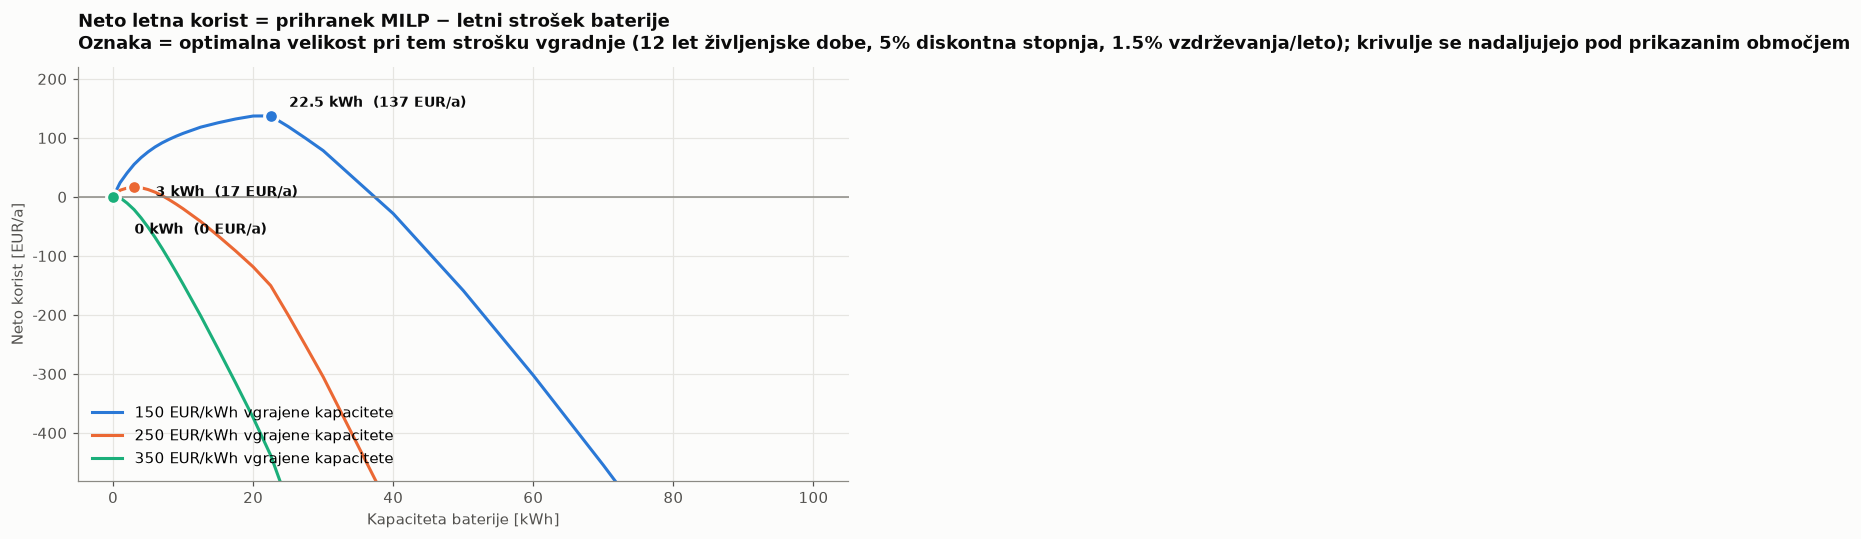

   150 EUR/kWh installed -> optimal  22.5 kWh, net   137.36 EUR/a
   250 EUR/kWh installed -> optimal   3.0 kWh, net    16.85 EUR/a
   350 EUR/kWh installed -> optimal   0.0 kWh, net     0.00 EUR/a


In [10]:
### Net annual benefit
fig, ax = plt.subplots(figsize=(9, 5))

optima = {}
label_offsets = [(12, 6), (14, -6), (14, -24)]
for capex, colour, offset in zip(CAPEX_SCENARIOS_EUR_PER_KWH, SERIES, label_offsets):
    net = df_sizing[f"Net_{int(capex)}"]
    ax.plot(cap, net, color=colour, lw=2, label=f"{capex:,.0f} EUR/kWh vgrajene kapacitete")
    best = int(net.idxmax())
    optima[capex] = (float(df_sizing["Capacity_kWh"][best]), float(net[best]))
    ax.plot([optima[capex][0]], [optima[capex][1]], marker="o", ms=9,
            color=colour, mfc=colour, mec=SURFACE, mew=2, zorder=3)
    ax.annotate(f"{optima[capex][0]:g} kWh  ({optima[capex][1]:,.0f} EUR/a)",
                xy=optima[capex], xytext=offset, textcoords="offset points",
                color=INK, fontsize=9, fontweight="semibold")

ax.axhline(0, color=MUTED, lw=1.0)
best_net = max(v for _, v in optima.values())
ax.set_ylim(-max(300.0, 3.5 * best_net), max(60.0, 1.6 * best_net))
finish(ax, "Neto letna korist = prihranek MILP − letni strošek baterije",
       "Kapaciteta baterije [kWh]", "Neto korist [EUR/a]",
       f"Oznaka = optimalna velikost pri tem strošku vgradnje "
       f"({BATTERY_LIFETIME_YEARS} let življenjske dobe, {DISCOUNT_RATE:.0%} diskontna stopnja, "
       f"{opex_factor:.1%} vzdrževanja/leto); "
       f"krivulje se nadaljujejo pod prikazanim območjem")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

for capex, (size, net) in optima.items():
    print(f"{capex:6.0f} EUR/kWh installed -> optimal {size:5.1f} kWh, "
          f"net {net:8.2f} EUR/a")

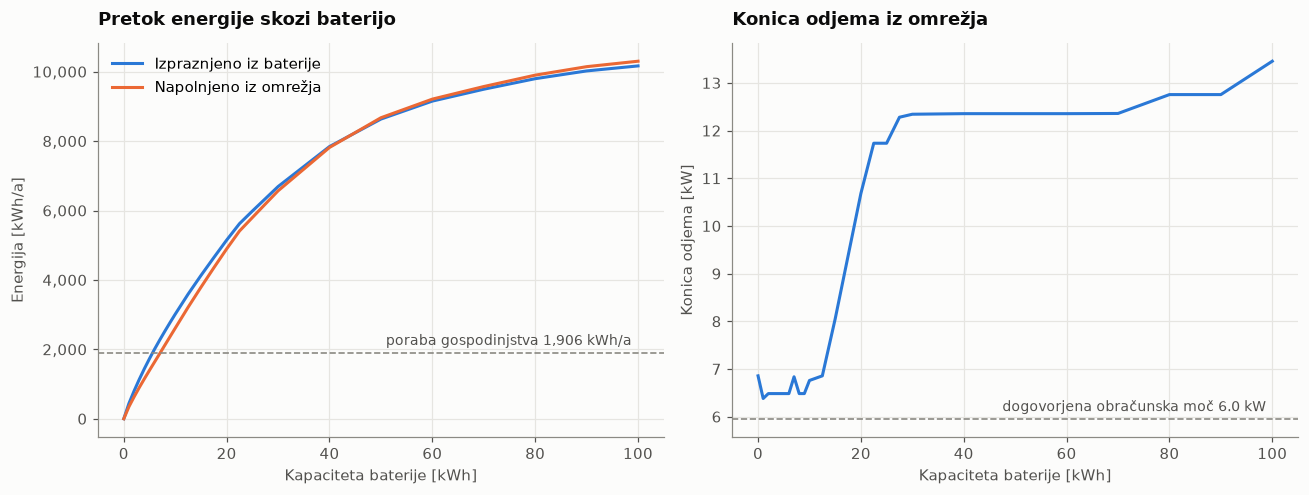

In [11]:
### Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
ax.plot(cap, df_sizing["Discharged_kWh"], color=SERIES[0], lw=2, label="Izpraznjeno iz baterije")
ax.plot(cap, df_sizing["Grid_Charged_kWh"], color=SERIES[1], lw=2, label="Napolnjeno iz omrežja")
ax.axhline(annual_consumption_kwh, color=MUTED, lw=1.1, ls="--")
ax.annotate(f"poraba gospodinjstva {annual_consumption_kwh:,.0f} kWh/a",
            xy=(cap.max(), annual_consumption_kwh), xytext=(-4, 5),
            textcoords="offset points", ha="right", color=INK_2, fontsize=9)
finish(ax, "Pretok energije skozi baterijo", "Kapaciteta baterije [kWh]", "Energija [kWh/a]")
ax.legend(loc="upper left")

ax = axes[1]
ax.plot(cap, df_sizing["Peak_Import_kW"], color=SERIES[0], lw=2)
contracted = float(list(build_env(0.0).contracted_power_kw.values())[0])
ax.axhline(contracted, color=MUTED, lw=1.1, ls="--")
ax.annotate(f"dogovorjena obračunska moč {contracted:,.1f} kW",
            xy=(cap.max(), contracted), xytext=(-4, 5), textcoords="offset points",
            ha="right", color=INK_2, fontsize=9)
finish(ax, "Konica odjema iz omrežja", "Kapaciteta baterije [kWh]", "Konica odjema [kW]")

plt.tight_layout()
plt.show()

## 7. Read-out

In [12]:
best_capex = CAPEX_SCENARIOS_EUR_PER_KWH[-1]
lines = [
    f"Household {HOUSEHOLD_ID} ({DATASET_NAME}) — {annual_consumption_kwh:,.0f} kWh/a consumed, "
    f"{annual_generation_kwh:,.0f} kWh/a PV",
    f"Tariff: {PAKET_ID} ({PRICING_SCHEME}), regime {PRICING_REFERENCE_YEAR}",
    f"Continuous MILP, {len(BATTERY_SIZES_KWH)} capacities from "
    f"{BATTERY_SIZES_KWH.min():.0f} to {BATTERY_SIZES_KWH.max():.0f} kWh",
    "",
    f"Cost without a battery          : {cost_no_battery:10,.2f} EUR/a",
    f"Cost at {BATTERY_SIZES_KWH.max():.0f} kWh                 : "
    f"{float(df_sizing['Cost_EUR'].iloc[-1]):10,.2f} EUR/a",
    f"Largest achievable saving       : {max_savings:10,.2f} EUR/a",
    f"95 % of it reached at           : {knee_kwh:10,.1f} kWh",
    "",
    "Optimal size by installed battery cost:",
]
for capex, (size, net) in optima.items():
    lines.append(f"   {capex:6,.0f} EUR/kWh -> {size:5.1f} kWh   (net {net:+8,.2f} EUR/a)")
lines += [
    "",
    "Break-even installed cost (EUR/kWh) — a battery of that size pays for itself below this:",
]
for _, r in df_sizing[df_sizing["Capacity_kWh"] > 0].iterrows():
    if r["Capacity_kWh"] in (5.0, 10.0, 20.0, 50.0, 100.0):
        lines.append(f"   {r['Capacity_kWh']:5.1f} kWh -> {r['Break_Even_Capex']:7,.0f} EUR/kWh"
                     f"   (simple payback at {REFERENCE_CAPEX:,.0f} EUR/kWh: "
                     f"{r['Payback_y']:5.1f} y)")

print("\n".join(lines))

Household 29 (Fluvius_PV) — 1,906 kWh/a consumed, 1,268 kWh/a PV
Tariff: GENI_SAMO_DINAMICNI (si_samooskrba), regime 2026
Continuous MILP, 26 capacities from 0 to 100 kWh

Cost without a battery          :     485.29 EUR/a
Cost at 100 kWh                 :    -488.76 EUR/a
Largest achievable saving       :     974.05 EUR/a
95 % of it reached at           :       90.0 kWh

Optimal size by installed battery cost:
      150 EUR/kWh ->  22.5 kWh   (net  +137.36 EUR/a)
      250 EUR/kWh ->   3.0 kWh   (net   +16.85 EUR/a)
      350 EUR/kWh ->   0.0 kWh   (net    +0.00 EUR/a)

Break-even installed cost (EUR/kWh) — a battery of that size pays for itself below this:
     5.0 kWh ->     270 EUR/kWh   (simple payback at 350 EUR/kWh:  12.0 y)
    10.0 kWh ->     234 EUR/kWh   (simple payback at 350 EUR/kWh:  14.2 y)
    20.0 kWh ->     204 EUR/kWh   (simple payback at 350 EUR/kWh:  16.8 y)
    50.0 kWh ->     125 EUR/kWh   (simple payback at 350 EUR/kWh:  32.6 y)
   100.0 kWh ->      76 EUR/kWh  

### Caveats

* **Perfect foresight.** Every point is an upper bound; a real controller captures only part.
* **0.1 % MIP gap**, roughly 0.4 EUR on this bill against ~20 EUR between capacities.
* **Arbitrage through the grid.** Exports are credited regardless of origin, so where the
  throughput panel shows a large grid-charged share the savings are trading revenue.
* **`peak_reset_months=None`** ratchets one peak across the year; `PEAK_RESET_MONTHS = 1` is
  the monthly settlement the SI regulation actually uses.
* **One year, one household.**